In [2]:
import torch
import torch.nn as nn
import numpy as np
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [3]:

## defining the device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using {device} device')

Using cpu device


In [4]:
#data into train an val

BATCH_SIZE= 128

from torchvision.transforms import Compose, ToTensor

data_transform = Compose([ToTensor()])

train_dataset = datasets.MNIST(root="./data", train=True, transform = data_transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

100.0%
100.0%
100.0%
100.0%


In [5]:
#class that defines autoencoder

class AutoEncoder(nn.Module):
  def __init__(self, latent_dim = 3, hidden_dim =256):
    super().__init__()

    #Encoder
    self.encoder = nn.Sequential(
        nn.Linear(784, hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, latent_dim),
        nn.ReLU()
    )


    #Decoder
    self.decoder = nn.Sequential(
        nn.Linear(latent_dim, hidden_dim),
        nn.ReLU(),
        nn.Linear(256, 784),
        nn.Sigmoid()
    )
  def forward(self, x):
    z = self.encoder(x)  
    x_recon = self.decoder(z)
    return x_recon

In [6]:

## defining the model , loss

model = AutoEncoder()

criterion= nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)


In [7]:
epochs = 5 
model.train()
for epoch in range(epochs):
  total_loss = 0
  for x, _ in train_loader:
    x = x.view(-1, 784)

    optimizer.zero_grad()
    x_recon = model(x)
    loss = criterion(x_recon, x)
    loss.backward()
    optimizer.step()

    total_loss = total_loss + loss.item()

  avg_loss = total_loss / len(train_loader)
  print(f'Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.6f}')



Epoch 1/5, Loss: 0.060874
Epoch 2/5, Loss: 0.051550
Epoch 3/5, Loss: 0.049579
Epoch 4/5, Loss: 0.048229
Epoch 5/5, Loss: 0.047186


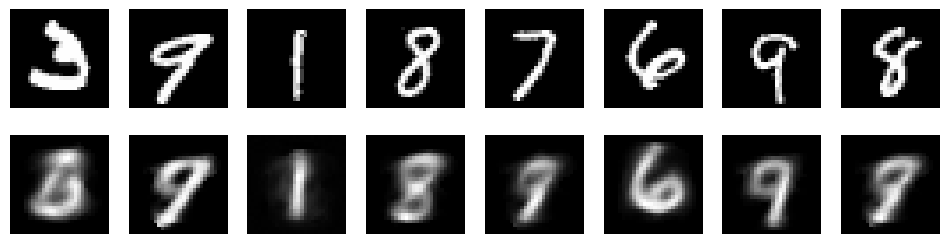

In [8]:
model.eval()

with torch.no_grad():
  x, _ = next(iter(train_loader))
  x = x.view(-1, 784).to(device)
  x_recon = model(x)
  n = 8
  plt.figure(figsize=(12,3))

  for i in range(n):
    ax = plt.subplot(2, n, i+1)
    plt.imshow(x[i].view(28,28), cmap="gray")
    plt.axis('off')

    plt.subplot(2,n,i+1+n)
    plt.imshow(x_recon[i].view(28,28), cmap="gray")
    plt.axis('off')

  plt.show()
  

In [16]:
model.eval()

latents = []
labels = []

with torch.no_grad():
  
  for x, y in train_loader:
    x = x.view(-1, 784).to(device)
    z = model.encoder(x)
    latents.append(z.cpu())
    labels.append(y)

latents = torch.cat(latents, dim=0)
labels = torch.cat(labels, dim=0)

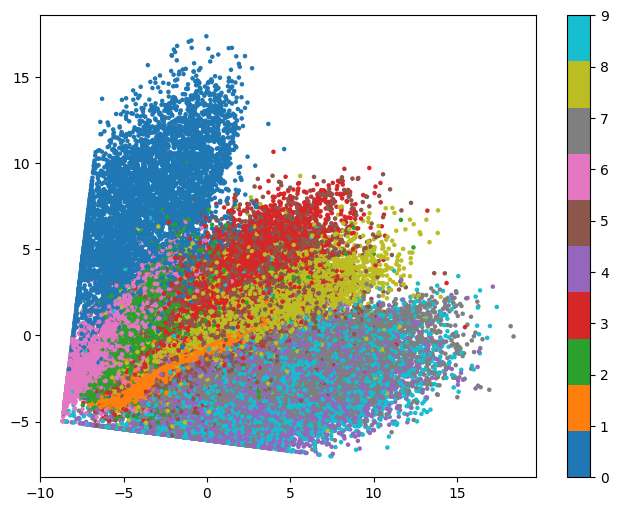

In [17]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

latent_dim = latents.shape[1]

# ensure numpy

Z = latents.detach().cpu().numpy()
Y = labels.detach().cpu().numpy()

if latent_dim == 2:
    plt.figure(figsize=(8,6))
    scatter = plt.scatter(
        Z[:,0],
        Z[:,1],
        c=Y,
        cmap='tab10',
        s=5
    )
    plt.colorbar(scatter)
    plt.show()

elif latent_dim > 2:
    pca = PCA(n_components=2)
    Z_pca = pca.fit_transform(Z)

    plt.figure(figsize=(8,6))
    scatter = plt.scatter(
        Z_pca[:,0],
        Z_pca[:,1],
        c=Y,
        cmap='tab10',
        s=5
    )
    plt.colorbar(scatter)
    plt.show()
